# Creating the AnnData File

#  Import required packages

In [4]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from pathlib import Path
import scimap as sm
import os
import yaml
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Required Inputs

In [6]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
metadata_dir = Path(config['metadata_dir'])
preprocessed_dir = Path(config['preprocessed_dir'])

# make a roi list of directories in preprocessed_dir that are not .DS_Store
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

patients_metadata = pd.read_csv(metadata_dir / 'new_patients_metadata.csv')

# Add the Patients Metadata to the ROIs

In [70]:
for roi in roi_list:
    exp = pd.read_csv(roi / "exp.csv")
    meta = pd.read_csv(roi / "metadata.csv")
    meta["exp_name"] = roi.name
    meta = meta.merge(patients_metadata, on="exp_name")
    meta.to_csv(roi / "metadata.csv", index=False)


## Create the Anndata Object for each ROI

In [73]:
for roi in roi_list:
    exp = pd.read_csv(roi / "exp.csv")
    meta = pd.read_csv(roi / "metadata.csv")
    #get the cells coordinates
    cells_coordinates = np.array([meta["Cell Center X"], meta["Cell Center Y"]]).T
    adata = ad.AnnData(X=exp.iloc[:,1:], obs=meta, obsm={"spatial": cells_coordinates})
    #write adata file
    adata.write(roi / "adata.h5ad")

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/li

# Anndata Concatenation

In [7]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [9]:
adata

AnnData object with n_obs × n_vars = 108121 × 77
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [11]:
adata_short = adata_all[adata_all.obs["outcome_group"] == "short_term survival"]
adata_short.raw = adata_short
adata_short = sm.pp.log1p(adata_short)

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [1]:
adata

NameError: name 'adata' is not defined

In [12]:
adata_short = sm.tl.spatial_distance (adata_short, phenotype='cell_type', imageid="exp_name", x_coordinate="Cell Center X", y_coordinate="Cell Center Y")

Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI23


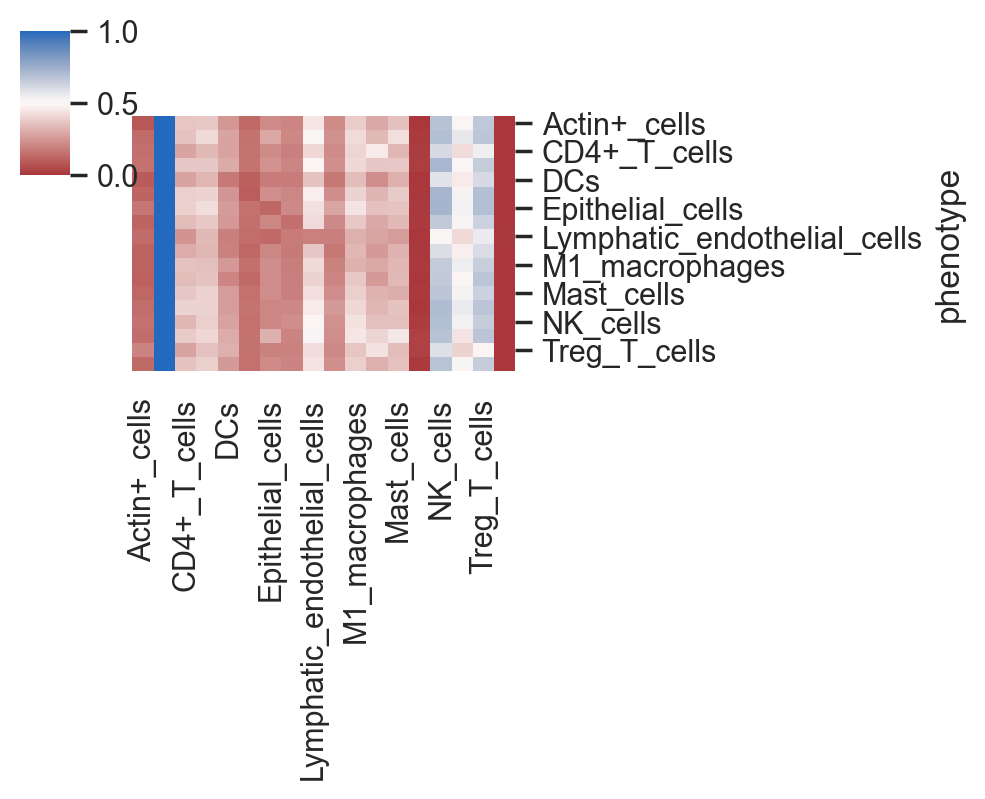

In [13]:
sm.pl.spatial_distance (adata_short, figsize=(5,4), phenotype="cell_type", imageid="exp_name")

In [125]:
batikh = pd.DataFrame(np.random.rand(5000, 5), columns=["Sample1", "Sample2", "Sample3", "Sample4", "Sample5"])
expr_data_normalized = (batikh - batikh.mean()) / batikh.std()
expr_data_normalized

,Sample1,Sample2,Sample3,Sample4,Sample5
0,-0.832410,-1.430242,1.165772,0.602395,-1.287738
1,0.939923,0.558405,-1.371925,-0.142978,-0.875860
2,0.371485,-1.035243,-0.582225,-0.857492,-1.443742
3,-0.289554,0.100026,0.041261,-0.447360,-0.046282
4,1.527875,1.337962,0.522834,0.576148,1.745707
...,...,...,...,...,...
4995,1.139268,-0.916404,-0.568562,-1.192981,-0.764666
4996,-0.115422,-0.797131,-0.883213,-1.396004,-1.096244
4997,0.311161,-1.352897,-1.577249,-0.484546,1.745265
4998,-1.261770,-1.325968,-1.692604,-0.338497,-1.335362


In [20]:
adata_all.var

""
Actin REAL650
Arginase-1 2
Bcl 2 REA872
beta Actin REAL571
beta Catenin REA480
...
CD274 REA1308
CD223 REA351
CD90 REAL677
p16 REA1325


In [28]:
adata.obs

,cell_id,cell_type,level,parent_cell,type_no,Cell 3D Volume,Cell Bbox Bottom,Cell Bbox Left,Cell Bbox Right,Cell Bbox Top,...,ROI index,exp_name,patient_ID,age at diagnosis,sex,site,outcome,run,rois,outcome_group
0,1,Tumor_cells,1,0,14,1006,24,2573,0,2625,...,0,Run141_ROI16,NMC_15,27,m,lung,4,141.0,16,short_term survival
1,2,Epithelial_cells,1,0,19,1615,36,2718,0,2776,...,0,Run141_ROI16,NMC_15,27,m,lung,4,141.0,16,short_term survival
2,3,Epithelial_cells,1,0,19,1865,61,2801,0,2839,...,0,Run141_ROI16,NMC_15,27,m,lung,4,141.0,16,short_term survival
3,4,Epithelial_cells,1,0,19,2057,54,2836,0,2889,...,0,Run141_ROI16,NMC_15,27,m,lung,4,141.0,16,short_term survival
4,5,Epithelial_cells,1,0,19,347,17,2885,0,2917,...,0,Run141_ROI16,NMC_15,27,m,lung,4,141.0,16,short_term survival
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16649,17974,Tumor_cells,1,0,14,3916,10069,8284,10019,8398,...,0,Run141_ROI23,NMC_21,36,m,"intrathoracic, right bronchus",4,141.0,23,short_term survival
16650,17975,Tumor_cells,1,0,14,606,10069,1489,10050,1535,...,0,Run141_ROI23,NMC_21,36,m,"intrathoracic, right bronchus",4,141.0,23,short_term survival
16651,17976,Tumor_cells,1,0,14,1234,10069,8150,10044,8222,...,0,Run141_ROI23,NMC_21,36,m,"intrathoracic, right bronchus",4,141.0,23,short_term survival
16652,17977,Tumor_cells,1,0,14,728,10069,4008,10046,4047,...,0,Run141_ROI23,NMC_21,36,m,"intrathoracic, right bronchus",4,141.0,23,short_term survival


In [36]:

# Basic usage with automatic comparison to all other groups
adata = sm.tl.foldchange(adata, from_group=['long_term survival'], imageid='outcome_group', phenotype='cell_type', normalize=True, label='roi_comparison')


calculating foldchange
calculating P values


/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/scimap/tools/foldchange.py:109: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['long_term survival', 'long_term survival', 'long_term survival', 'long_term survival', 'long_term survival', ..., 'long_term survival', 'long_term survival', 'long_term survival', 'long_term survival', 'long_term survival']
Length: 50825
Categories (1, object): ['long_term survival']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/scimap/tools/foldchange.py:110: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Tumor_cells', 'NFC', 'M1_macrophages', 'MDSCs', 'Tumor_cells', ..., 'NFC', 'Tumor_cells', 'Tumor_cells', 'Tumor_cells', 'Tumor_cells']
Length: 50825
Categories (18, ob

In [40]:
adata

AnnData object with n_obs × n_vars = 108121 × 77
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

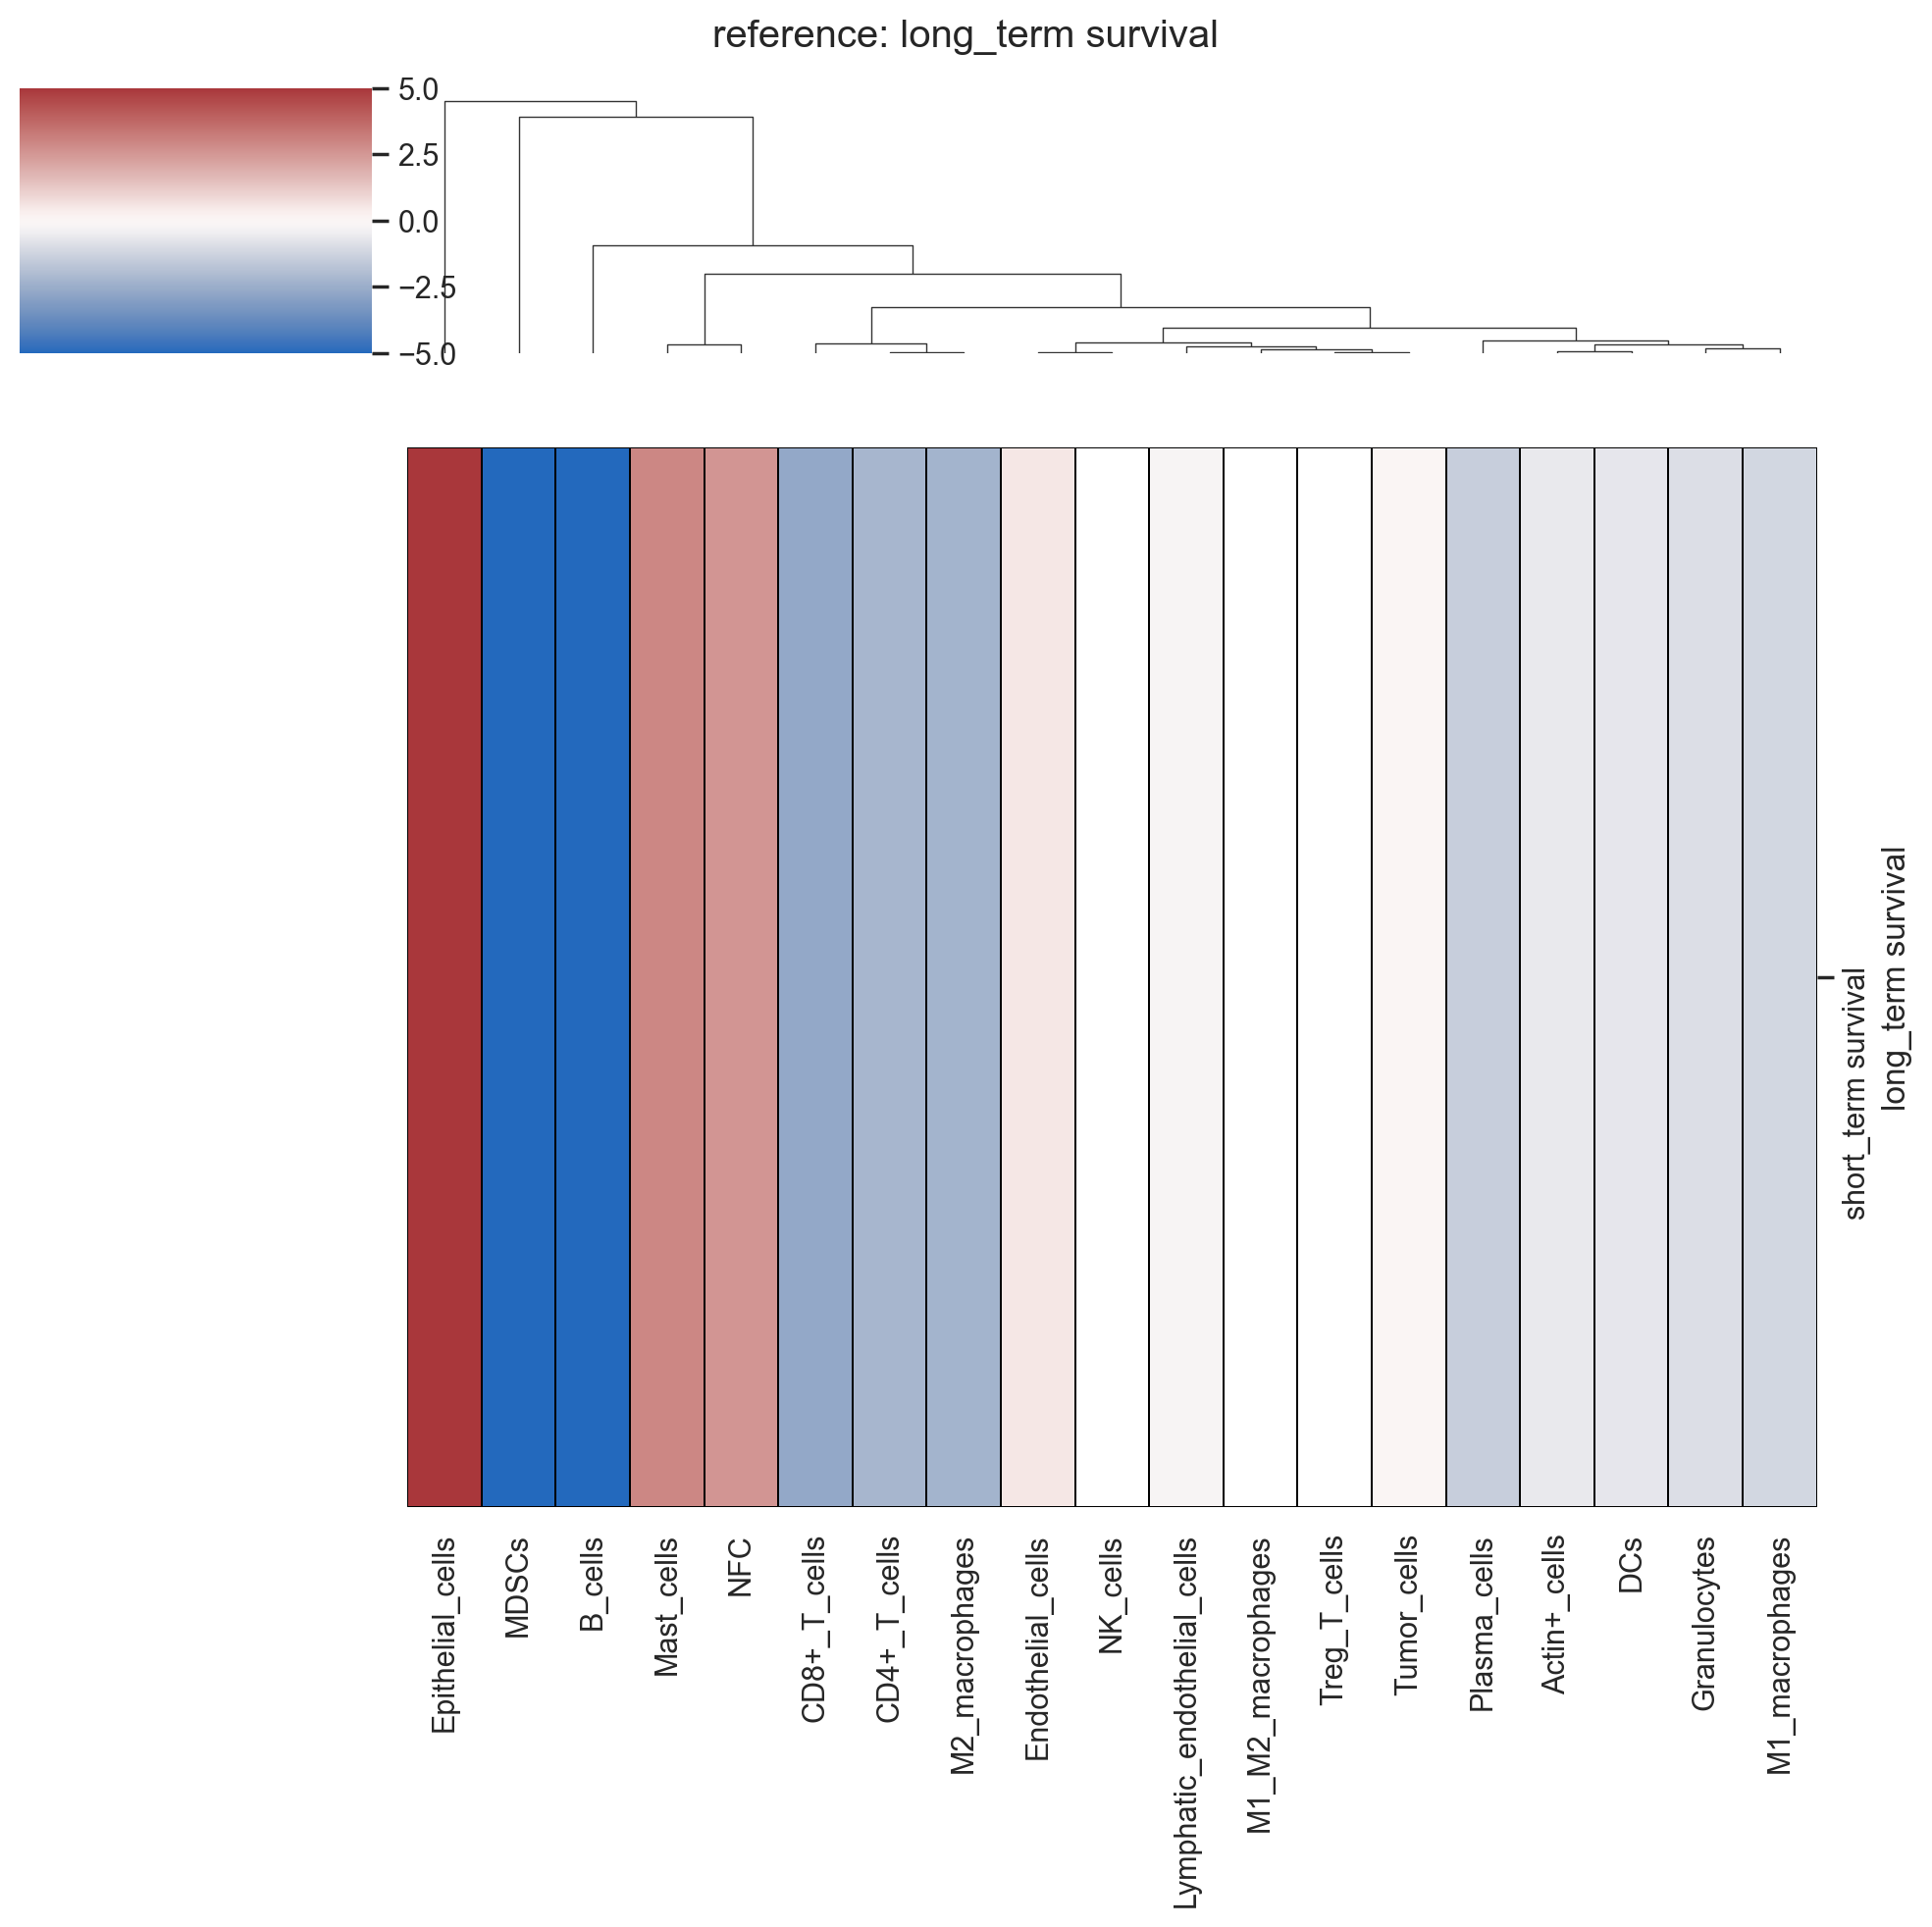

In [41]:
sm.pl.foldchange (adata, label='roi_comparison', method='heatmap',
                  p_val=0.05, nonsig_color='grey',
                  cmap = 'vlag', log=True, center=0, linecolor='black',linewidths=0.7,
                  vmin=-5, vmax=5, row_cluster=False)